In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

import warnings
warnings.filterwarnings("ignore")

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/Project /framingham.csv')

In [ ]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
df.shape

(4240, 16)

In [ ]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [ ]:
print(df.columns.tolist())

['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']


In [ ]:
print("Shape:", df.shape)

df.head()

Shape: (4240, 16)


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4240 entries, 0 to 4239
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4240 non-null   int64  
 1   age              4240 non-null   int64  
 2   education        4135 non-null   float64
 3   currentSmoker    4240 non-null   int64  
 4   cigsPerDay       4211 non-null   float64
 5   BPMeds           4187 non-null   float64
 6   prevalentStroke  4240 non-null   int64  
 7   prevalentHyp     4240 non-null   int64  
 8   diabetes         4240 non-null   int64  
 9   totChol          4190 non-null   float64
 10  sysBP            4240 non-null   float64
 11  diaBP            4240 non-null   float64
 12  BMI              4221 non-null   float64
 13  heartRate        4239 non-null   float64
 14  glucose          3852 non-null   float64
 15  TenYearCHD       4240 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 530.1 KB


In [ ]:
print(df.isnull().sum())

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64


In [ ]:
print("Total Missing Values:",
      df.isnull().sum().sum())

Total Missing Values: 645


In [ ]:
print(df['TenYearCHD'].value_counts())

TenYearCHD
0    3596
1     644
Name: count, dtype: int64


In [ ]:
print(
    df['TenYearCHD']
    .value_counts(normalize=True)*100
)

TenYearCHD
0    84.811321
1    15.188679
Name: proportion, dtype: float64


In [ ]:
df.isnull().sum().sort_values(ascending=False)

,0
glucose,388
education,105
BPMeds,53
totChol,50
cigsPerDay,29
BMI,19
heartRate,1
male,0
prevalentHyp,0
prevalentStroke,0


In [ ]:
num_cols = [
    'cigsPerDay',
    'totChol',
    'BMI',
    'heartRate',
    'glucose'
]

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [ ]:
df['education'] = df['education'].fillna(
    df['education'].mode()[0]
)



In [ ]:
df['BPMeds'] = df['BPMeds'].fillna(
    df['BPMeds'].mode()[0]
)

In [ ]:
print(df.isnull().sum())

male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64


In [ ]:
print("Duplicate Rows:",
      df.duplicated().sum())

Duplicate Rows: 0


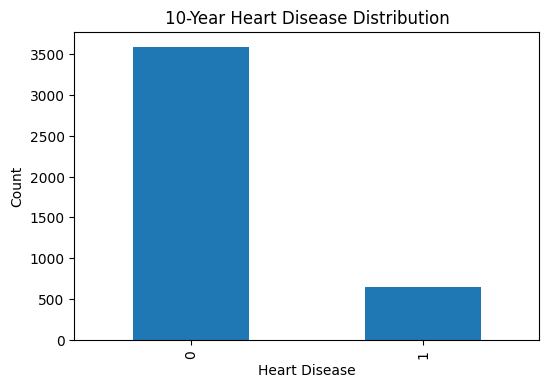

In [ ]:
plt.figure(figsize=(6,4))

df['TenYearCHD'].value_counts().plot(
    kind='bar'
)

plt.title("10-Year Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")

plt.show()

In [ ]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000,4240.000000
mean,0.429245,49.580189,1.955189,0.494104,8.944340,0.029245,0.005896,0.310613,0.025708,236.667689,132.354599,82.897759,25.799005,75.878774,81.600943,0.151887
std,0.495027,8.572942,1.018522,0.500024,11.904777,0.168513,0.076569,0.462799,0.158280,44.328480,22.033300,11.910394,4.070775,12.023937,22.860340,0.358953
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.077500,68.000000,72.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,262.000000,144.000000,90.000000,28.032500,83.000000,85.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


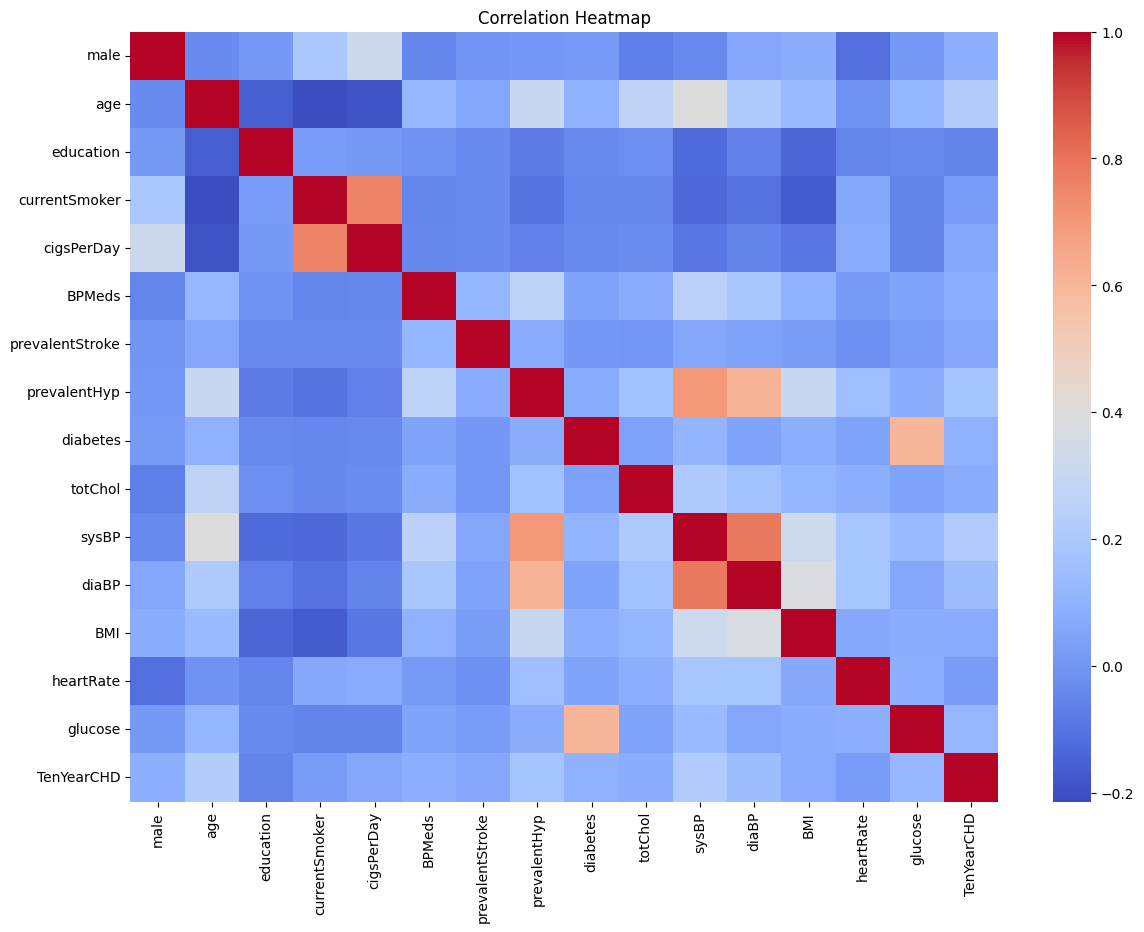

In [ ]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title("Correlation Heatmap")
plt.show()

In [ ]:
corr_target = df.corr()['TenYearCHD'].sort_values(
    ascending=False
)

print(corr_target)

TenYearCHD         1.000000
age                0.225408
sysBP              0.216374
prevalentHyp       0.177458
diaBP              0.145112
glucose            0.121319
diabetes           0.097344
male               0.088374
BPMeds             0.086448
totChol            0.081749
BMI                0.074326
prevalentStroke    0.061823
cigsPerDay         0.058729
heartRate          0.022851
currentSmoker      0.019448
education         -0.053002
Name: TenYearCHD, dtype: float64


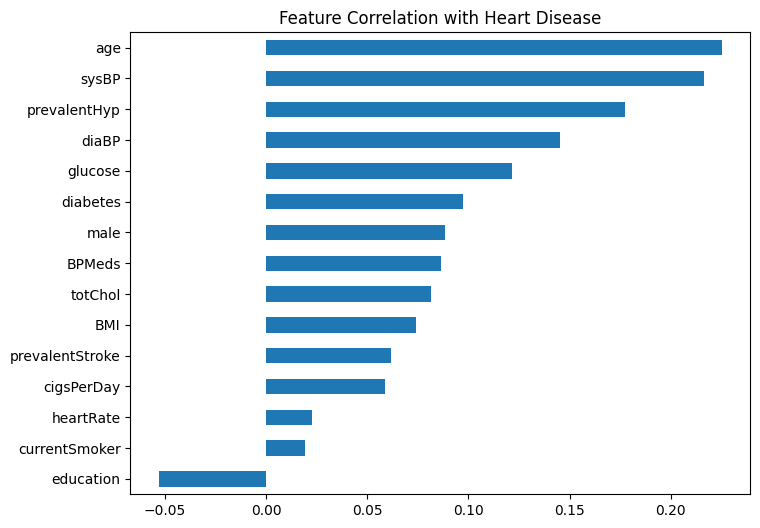

In [ ]:
corr_target.drop('TenYearCHD').sort_values().plot(
    kind='barh',
    figsize=(8,6)
)

plt.title("Feature Correlation with Heart Disease")
plt.show()

In [ ]:
X = df.drop('TenYearCHD', axis=1)

y = df['TenYearCHD']

print(X.shape)
print(y.shape)

(4240, 15)
(4240,)


In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(3392, 15)
(848, 15)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [ ]:
print(X_train_scaled.shape)
print(X_test_scaled.shape)

(3392, 15)
(848, 15)


In [ ]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_lr))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_lr))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_lr
))

Accuracy: 0.8443396226415094

Confusion Matrix
[[709  10]
 [122   7]]

Classification Report
              precision    recall  f1-score   support

           0       0.85      0.99      0.91       719
           1       0.41      0.05      0.10       129

    accuracy                           0.84       848
   macro avg       0.63      0.52      0.51       848
weighted avg       0.79      0.84      0.79       848



In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=300,
                       random_state=42)

In [ ]:
y_pred_rf = rf.predict(X_test)

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_rf
))

Accuracy: 0.8077830188679245

Confusion Matrix
[[657  62]
 [101  28]]

Classification Report
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       719
           1       0.31      0.22      0.26       129

    accuracy                           0.81       848
   macro avg       0.59      0.57      0.57       848
weighted avg       0.78      0.81      0.79       848



In [ ]:
!pip install xgboost -q

In [ ]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    scale_pos_weight=5.5,
    random_state=42,
    eval_metric='logloss'
)

xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [ ]:
y_pred_xgb = xgb.predict(X_test)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_xgb))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred_xgb))

print("\nClassification Report")
print(classification_report(
    y_test,
    y_pred_xgb
))

Accuracy: 0.7004716981132075

Confusion Matrix
[[539 180]
 [ 74  55]]

Classification Report
              precision    recall  f1-score   support

           0       0.88      0.75      0.81       719
           1       0.23      0.43      0.30       129

    accuracy                           0.70       848
   macro avg       0.56      0.59      0.56       848
weighted avg       0.78      0.70      0.73       848



In [ ]:
from sklearn.metrics import roc_auc_score

y_prob = xgb.predict_proba(X_test)[:,1]

auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC:", auc)

ROC-AUC: 0.6299662537331134


In [ ]:
!pip install imbalanced-learn -q

In [ ]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(
    sampling_strategy='auto',
    random_state=42
)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(5754, 15)
TenYearCHD
0    2877
1    2877
Name: count, dtype: int64


In [ ]:
lr_smote = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
y_pred_smote = lr_smote.predict(X_test_scaled)

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)

print("Accuracy:",
      accuracy_score(y_test, y_pred_smote))

print(confusion_matrix(y_test, y_pred_smote))

print(classification_report(
    y_test,
    y_pred_smote
))

y_prob = lr_smote.predict_proba(X_test_scaled)[:,1]

print(
    "ROC-AUC:",
    roc_auc_score(y_test, y_prob)
)

Accuracy: 0.6662735849056604
[[488 231]
 [ 52  77]]
              precision    recall  f1-score   support

           0       0.90      0.68      0.78       719
           1       0.25      0.60      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80      0.67      0.71       848

ROC-AUC: 0.6962189086910113


In [ ]:
import pickle

pickle.dump(
    lr_smote,
    open("heart_model.pkl", "wb")
)

pickle.dump(
    scaler,
    open("heart_scaler.pkl", "wb")
)

In [ ]:
feature_names = X.columns.tolist()

print(feature_names)

['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


In [ ]:
pickle.dump(
    feature_names,
    open("heart_features.pkl", "wb")
)

In [ ]:
sample = [[
    1,      # male
    55,     # age
    2,      # education
    1,      # smoker
    15,     # cigarettes/day
    0,      # BP meds
    0,      # stroke
    1,      # hypertension
    0,      # diabetes
    240,    # cholesterol
    150,    # sysBP
    95,     # diaBP
    30,     # BMI
    80,     # heart rate
    110     # glucose
]]

In [ ]:
sample_scaled = scaler.transform(sample)

risk = lr_smote.predict_proba(
    sample_scaled
)[0][1]

print("Risk:", risk)

Risk: 0.7393126269903747


In [ ]:
import pandas as pd

importance = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_smote.coef_[0]
})

importance['Absolute'] = abs(
    importance['Coefficient']
)

importance = importance.sort_values(
    by='Absolute',
    ascending=False
)

print(importance)

            Feature  Coefficient  Absolute
1               age     0.690912  0.690912
4        cigsPerDay     0.256866  0.256866
10            sysBP     0.210560  0.210560
0              male     0.202019  0.202019
14          glucose     0.127281  0.127281
9           totChol     0.120082  0.120082
11            diaBP     0.117027  0.117027
5            BPMeds     0.106989  0.106989
6   prevalentStroke     0.085254  0.085254
13        heartRate    -0.071279  0.071279
7      prevalentHyp     0.059402  0.059402
3     currentSmoker     0.054583  0.054583
2         education    -0.046139  0.046139
8          diabetes     0.039987  0.039987
12              BMI     0.017353  0.017353


In [ ]:
y_prob = lr_smote.predict_proba(X_test_scaled)[:,1]

for threshold in [0.3, 0.4, 0.5]:

    y_pred = (y_prob >= threshold).astype(int)

    print("\nThreshold:", threshold)

    print(classification_report(
        y_test,
        y_pred
    ))


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.38      0.54       719
           1       0.20      0.88      0.33       129

    accuracy                           0.45       848
   macro avg       0.58      0.63      0.43       848
weighted avg       0.83      0.45      0.51       848


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.54      0.68       719
           1       0.22      0.74      0.34       129

    accuracy                           0.57       848
   macro avg       0.57      0.64      0.51       848
weighted avg       0.81      0.57      0.63       848


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.90      0.68      0.78       719
           1       0.25      0.60      0.35       129

    accuracy                           0.67       848
   macro avg       0.58      0.64      0.56       848
weighted avg       0.80   

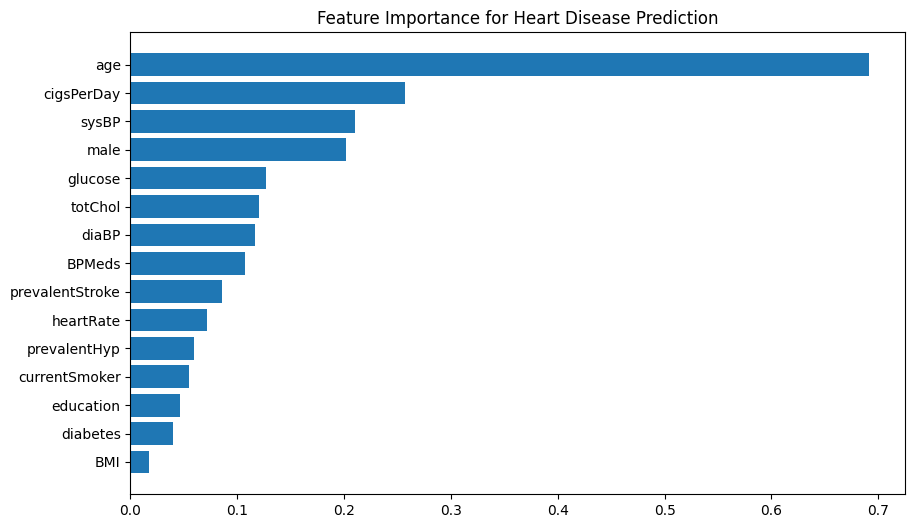

In [ ]:
importance = importance.sort_values(
    by='Absolute',
    ascending=True
)

plt.figure(figsize=(10,6))

plt.barh(
    importance['Feature'],
    importance['Absolute']
)

plt.title(
    "Feature Importance for Heart Disease Prediction"
)

plt.show()

In [ ]:
y_prob = lr_smote.predict_proba(X_test_scaled)[:,1]

print(y_prob[:10])

[0.28458583 0.12644263 0.49567346 0.17818833 0.58018818 0.25974905
 0.14931715 0.61151546 0.09442486 0.77280814]


In [ ]:
from sklearn.metrics import classification_report

for threshold in [0.20, 0.30, 0.40, 0.50, 0.60]:

    y_pred = (y_prob >= threshold).astype(int)

    print("\n" + "="*50)
    print("Threshold:", threshold)
    print("="*50)

    print(classification_report(
        y_test,
        y_pred
    ))


Threshold: 0.2
              precision    recall  f1-score   support

           0       0.94      0.18      0.31       719
           1       0.17      0.94      0.29       129

    accuracy                           0.30       848
   macro avg       0.56      0.56      0.30       848
weighted avg       0.83      0.30      0.30       848


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.95      0.38      0.54       719
           1       0.20      0.88      0.33       129

    accuracy                           0.45       848
   macro avg       0.58      0.63      0.43       848
weighted avg       0.83      0.45      0.51       848


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.92      0.54      0.68       719
           1       0.22      0.74      0.34       129

    accuracy                           0.57       848
   macro avg       0.57      0.64      0.51       848
weighted avg       0.81   

In [ ]:
from sklearn.metrics import precision_score, recall_score, f1_score

results = []

for threshold in [0.20, 0.30, 0.40, 0.50, 0.60]:

    y_pred = (y_prob >= threshold).astype(int)

    results.append([
        threshold,
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ])

import pandas as pd

threshold_results = pd.DataFrame(
    results,
    columns=[
        "Threshold",
        "Precision",
        "Recall",
        "F1"
    ]
)

print(threshold_results)

   Threshold  Precision    Recall        F1
0        0.2   0.170663  0.937984  0.288783
1        0.3   0.202847  0.883721  0.329957
2        0.4   0.221445  0.736434  0.340502
3        0.5   0.250000  0.596899  0.352403
4        0.6   0.272727  0.418605  0.330275


In [ ]:
import pickle

pickle.dump(
    lr_smote,
    open("heart_model.pkl", "wb")
)

pickle.dump(
    scaler,
    open("heart_scaler.pkl", "wb")
)

pickle.dump(
    feature_names,
    open("heart_features.pkl", "wb")
)

In [ ]:
from google.colab import files

files.download("heart_model.pkl")
files.download("heart_scaler.pkl")
files.download("heart_features.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>